In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [21]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [22]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [23]:
model = keras.Sequential(
  [
    keras.Input(shape=(4,)),
    layers.Dense(8, activation="relu", name="layer1"),
    layers.Dense(8, activation="relu", name="layer2"),
    layers.Dense(8, activation="relu", name="layer3"),
    layers.Dense(3, activation="softmax", name="layer4"),
  ]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211 (844.00 B)

 Trainable params: 211 (844.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
y = model(X)
print(y[149])

tf.Tensor([0.79908645 0.02941594 0.17149763], shape=(3,), dtype=float32)


In [25]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.CategoricalCrossentropy()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2844  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9729 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9215 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8804 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7903 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7339 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7002 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6340 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5895 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5607 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5340 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5097 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4957 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4707 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4556 
Epoch 16/500
5/5 ━

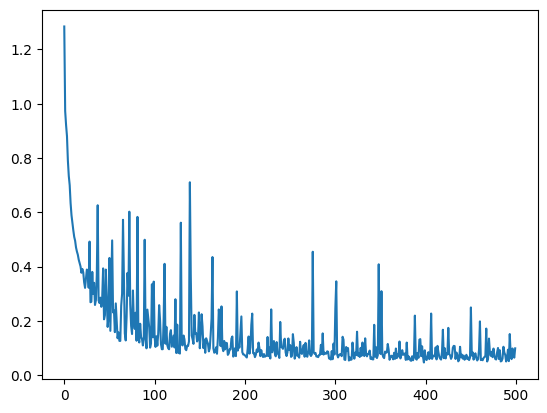

In [26]:
plt.plot(history.history['loss'])
plt.show()

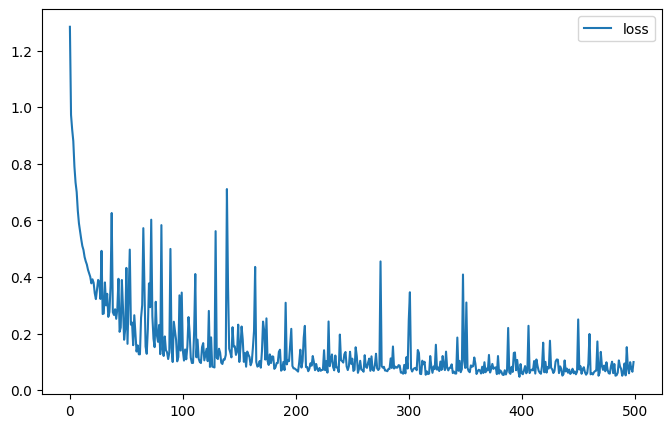

In [27]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

## Comentario sobre la Gráfica de Pérdida 'Caótica'

Observando la gráfica de pérdida generada, que se percibe como 'caótica', es importante analizar las posibles razones y lo que esto implica para el entrenamiento del modelo:

1.  **Oscilaciones y Falta de Convergencia Suave:** Una gráfica de pérdida que parece caótica (con muchas subidas y bajadas abruptas, o una falta de una tendencia descendente clara y suave) indica que el proceso de optimización está luchando para encontrar un mínimo estable en la función de pérdida. En lugar de converger suavemente, los pesos del modelo están siendo ajustados de manera errática, lo que puede deberse a varias causas.

2.  **Tamaño del Dataset (Iris: 150 ejemplos):** Con solo 150 ejemplos, el dataset Iris es muy pequeño. Cuando se entrena un modelo con un dataset tan limitado, cada epoch procesa el mismo conjunto de datos una y otra vez. Si el tamaño del lote (batch size) es pequeño o si el dataset es ruidoso, los gradientes calculados en cada paso pueden ser muy variables, lo que lleva a actualizaciones de pesos inestables y a estas fluctuaciones caóticas en la pérdida.

3.  **Tasa de Aprendizaje (`learning_rate=0.03`):** Aunque no es extremadamente alta, para un dataset pequeño y un modelo que ahora es un poco más complejo (con más neuronas en las capas ocultas), una tasa de aprendizaje de 0.03 podría ser demasiado agresiva. Una tasa de aprendizaje alta puede hacer que el optimizador 'salte' el mínimo óptimo, oscilando alrededor de él o incluso divergiendo, lo que se manifestaría como una pérdida caótica.

4.  **Complejidad del Modelo para el Dataset:** Hemos aumentado el número de neuronas en las capas ocultas a 8 (4x8x8x8x3). Para un dataset de 150 ejemplos, un modelo con tantas capas ocultas y un total de 283 parámetros (según `model.summary()` si la red fuera de 4x8x8x8x3) es **relativamente complejo**. Esto aumenta significativamente el riesgo de **sobreajuste (overfitting)**. El modelo puede estar aprendiendo los detalles específicos y el ruido de los ejemplos de entrenamiento en lugar de las relaciones generales, lo que puede hacer que la pérdida fluctúe a medida que intenta encajar cada punto de datos perfectamente, sin generalizar bien.

5.  **Activación ReLU:** Si bien ReLU es excelente para combatir el problema de los gradientes desvanecidos, también puede introducir el problema de las 'neuronas muertas' si la tasa de aprendizaje es demasiado alta y un gran número de neuronas entran en un estado donde siempre producen una salida de cero. Esto podría contribuir a la inestabilidad en el entrenamiento.

### Conclusión y Próximos Pasos:

La gráfica caótica sugiere que el modelo podría estar sobreajustándose al pequeño dataset de Iris o que el proceso de entrenamiento es inestable. Para abordar esto, se podrían considerar los siguientes ajustes:

*   **Reducir la tasa de aprendizaje:** Experimentar con valores más pequeños (e.g., 0.01, 0.001) para permitir que el optimizador converja de manera más suave.
*   **Añadir regularización:** Técnicas como `Dropout` o regularización L1/L2 en las capas densas pueden ayudar a prevenir el sobreajuste, forzando al modelo a aprender representaciones más generalizables.
*   **Reducir la complejidad del modelo:** Intentar con menos neuronas en las capas ocultas (e.g., 4x4x4x3) o menos capas ocultas si el sobreajuste es severo. El dataset Iris a menudo no requiere redes muy profundas.
*   **Aumentar el tamaño del lote (batch size):** Si el batch size actual es muy pequeño, aumentarlo puede dar gradientes más estables, aunque para el dataset Iris, el batch size ya sería todo el dataset.

In [28]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


array([[9.8856378e-01, 1.1436195e-02, 1.0814071e-12]], dtype=float32)

## Arquitectura de la Red Neuronal

La red neuronal es un modelo secuencial de Keras con las siguientes capas:

*   **Capa de Entrada (`keras.Input`):** Define la forma de los datos de entrada al modelo, `shape=(4,)`.
*   **Capa 1 (layer1):** Una capa `Dense` (totalmente conectada) con 8 unidades y función de activación 'relu'.
*   **Capa 2 (layer2):** Una capa `Dense` con 8 unidades y función de activación 'relu'.
*   **Capa 3 (layer3):** Una capa `Dense` con 8 unidades y función de activación 'relu'.
*   **Capa 4 (layer4):** La capa de salida, una capa `Dense` con 3 unidades y función de activación 'softmax'.

Este modelo está diseñado para clasificar las 4 características de entrada en 3 posibles clases de salida, utilizando activaciones ReLU en las capas ocultas y Softmax en la capa de salida para las probabilidades.

## Reporte Detallado del Modelo Keras

Este modelo de red neuronal se ha construido utilizando la API `Sequential` de Keras, lo que indica una pila lineal de capas.

### Topology (Topología)

El modelo consiste en las siguientes capas, organizadas secuencialmente:

1.  **Capa de Entrada (`keras.Input`):** Define la forma de los datos de entrada al modelo. En este caso, `shape=(4,)` indica que cada muestra de entrada es un vector de 4 características.
2.  **Capa Densa 1 (`layer1`):** Una capa `Dense` con 8 unidades (neuronas) y una función de activación `relu` (Rectified Linear Unit).
3.  **Capa Densa 2 (`layer2`):** Otra capa `Dense` con 8 unidades y activación `relu`.
4.  **Capa Densa 3 (`layer3`):** Similar a la anterior, una capa `Dense` con 8 unidades y activación `relu`.
5.  **Capa Densa 4 (`layer4`):** La última capa `Dense` y de salida, con 3 unidades y activación `softmax`. Esta capa produce 3 valores que pueden interpretarse como probabilidades para las 3 clases (especies de Iris), asegurando que la suma de estas probabilidades sea 1.

Cada capa `Dense` aplica una transformación lineal a sus entradas ($Z = XW + b$) seguida de una función de activación no lineal. Para las capas ocultas, ReLU ($A = \max(0, Z)$) introduce no linealidad, mientras que Softmax en la salida es adecuada para problemas de clasificación multiclase.

### Weight Initialization (Inicialización de Pesos)

La inicialización de los pesos (matrices de pesos $W$ y vectores de sesgo $b$) es un paso crucial para el entrenamiento efectivo de las redes neuronales. Una mala inicialización puede llevar a problemas como gradientes desvanecidos o explosivos.

*   **Keras (por defecto):** Cuando defines una capa `Dense` en Keras y no especificas explícitamente un inicializador de pesos (`kernel_initializer`) o de sesgos (`bias_initializer`), Keras utiliza inicializadores predeterminados que han demostrado ser efectivos para la mayoría de los casos. Para la capa `Dense`, el `kernel_initializer` predeterminado suele ser `GlorotUniform` (también conocido como Xavier uniform initializer) y el `bias_initializer` suele ser `zeros` (inicializando los sesgos a cero).
    *   `GlorotUniform` selecciona muestras aleatorias de una distribución uniforme dentro de un rango determinado por el número de entradas y salidas de la capa, lo que ayuda a mantener las varianzas de las activaciones y los gradientes en un nivel saludable a través de la red, facilitando un entrenamiento más estable. Es particularmente adecuado para activaciones `sigmoid` y `tanh`. Para `relu`, `HeNormal` es a menudo preferido, pero `GlorotUniform` sigue siendo una opción razonable.
    *   Inicializar los sesgos a cero es una práctica común y segura, ya que los sesgos pueden aprenderse rápidamente a partir de los gradientes durante el entrenamiento.

*   **Implementación Manual:** En una implementación manual, el desarrollador tendría que escribir código explícito para generar estos valores aleatorios o ceros para cada matriz de pesos y vector de sesgos de cada capa, asegurándose de que sigan distribuciones y rangos adecuados, lo cual es propenso a errores y requiere un conocimiento profundo de los principios de inicialización.

### Forward Propagation (Propagación Hacia Adelante)

La propagación hacia adelante es el proceso por el cual los datos de entrada pasan a través de la red neuronal, capa por capa, para producir una salida.

*   **Keras:** Keras automatiza completamente este proceso. Una vez que el modelo está definido, llamar a `model(X)` o `model.predict(X)` para nuevas entradas ejecuta la propagación hacia adelante. Internamente, Keras gestiona la aplicación secuencial de las operaciones de cada capa: primero la multiplicación de la matriz de entrada con los pesos de la capa, la suma de los sesgos y luego la aplicación de la función de activación (ReLU para las capas ocultas, Softmax para la capa de salida). No necesitamos preocuparnos por las matemáticas de bajo nivel.

*   **Implementación Manual:** En una implementación manual, tendrías que codificar explícitamente cada paso: para cada capa, calcular $Z = XW + b$ usando operaciones de álgebra lineal (multiplicaciones de matrices y sumas de vectores), y luego aplicar la función de activación correspondiente (ReLU o Softmax). Esto se repetiría para cada capa de la red, pasando la salida de una capa como entrada a la siguiente.

### Training (Entrenamiento)

El entrenamiento implica ajustar los pesos y sesgos del modelo para minimizar una función de pérdida (error) entre las predicciones del modelo y las etiquetas verdaderas, utilizando un optimizador.

*   **Keras:** El proceso de entrenamiento en Keras se simplifica enormemente con el método `model.compile()` y `model.fit()`.
    *   **Compilación:** Se definió el optimizador como `tf.keras.optimizers.SGD(learning_rate=0.03)`, que es el algoritmo de descenso de gradiente estocástico con una tasa de aprendizaje de 0.03. La función de pérdida es `tf.keras.losses.CategoricalCrossentropy()`, que es adecuada para problemas de clasificación multiclase donde las etiquetas están en formato one-hot encoded. Al llamar a `model.compile(optimizer, loss)`, Keras prepara el modelo para el entrenamiento.
    *   **Ajuste (`model.fit`):** La llamada a `history = model.fit(X, Y, epochs=500)` inicia el entrenamiento. Durante cada época, el modelo realiza los siguientes pasos internamente:
        1.  **Propagación hacia adelante:** Las entradas `X` pasan a través de la red para generar las predicciones `y_pred`.
        2.  **Cálculo de la Pérdida:** Se calcula el valor de la `CategoricalCrossentropy` entre `y_pred` y las etiquetas `Y`.
        3.  **Backpropagation (Propagación Hacia Atrás):** Keras (a través de TensorFlow y su sistema de diferenciación automática, `tf.GradientTape`) calcula automáticamente los gradientes de la función de pérdida con respecto a cada peso y sesgo en la red. Esto es fundamental para actualizar los parámetros del modelo de manera eficiente, sin que el usuario tenga que derivar manualmente las complejas ecuaciones de gradiente.
        4.  **Actualización de Pesos:** El optimizador `SGD` utiliza estos gradientes calculados para ajustar los pesos y sesgos del modelo de una manera que reduce la función de pérdida. La fórmula básica de actualización para SGD es $W = W - \alpha \nabla L$, donde $\alpha$ es la tasa de aprendizaje y $\nabla L$ es el gradiente de la pérdida.

*   **Implementación Manual:** Una implementación manual del entrenamiento implicaría:
    *   Derivar manualmente las ecuaciones para los gradientes de la función de pérdida (`CategoricalCrossentropy`) con respecto a cada peso y sesgo en cada capa, considerando las activaciones ReLU y Softmax (un proceso matemáticamente intensivo y propenso a errores).
    *   Codificar estas ecuaciones.
    *   Implementar un bucle de entrenamiento que realice la propagación hacia adelante, calcule la pérdida, aplique las ecuaciones de backpropagation para obtener los gradientes y luego actualice manualmente cada peso y sesgo utilizando el optimizador elegido. Esto requiere un control granular y una comprensión profunda de todos los aspectos matemáticos y algorítmicos, siendo una tarea significativamente más compleja que con Keras.